In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, roc_curve, auc

In [5]:
# Load the Data
url = "https://raw.githubusercontent.com/sharmaroshan/Heart-UCI-Dataset/master/heart.csv"
df = pd.read_csv(url)
df.sample(5)

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
67,45,0,1,130,234,0,0,175,0,0.6,1,0,2,1
277,57,1,1,124,261,0,1,141,0,0.3,2,0,3,0
117,56,1,3,120,193,0,0,162,0,1.9,1,0,3,1
148,44,1,2,120,226,0,1,169,0,0.0,2,0,2,1
254,59,1,3,160,273,0,0,125,0,0.0,2,0,2,0


In [6]:
# Check the Data
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    int64  
 1   sex       303 non-null    int64  
 2   cp        303 non-null    int64  
 3   trestbps  303 non-null    int64  
 4   chol      303 non-null    int64  
 5   fbs       303 non-null    int64  
 6   restecg   303 non-null    int64  
 7   thalach   303 non-null    int64  
 8   exang     303 non-null    int64  
 9   oldpeak   303 non-null    float64
 10  slope     303 non-null    int64  
 11  ca        303 non-null    int64  
 12  thal      303 non-null    int64  
 13  target    303 non-null    int64  
dtypes: float64(1), int64(13)
memory usage: 33.3 KB


the data is clean move forward

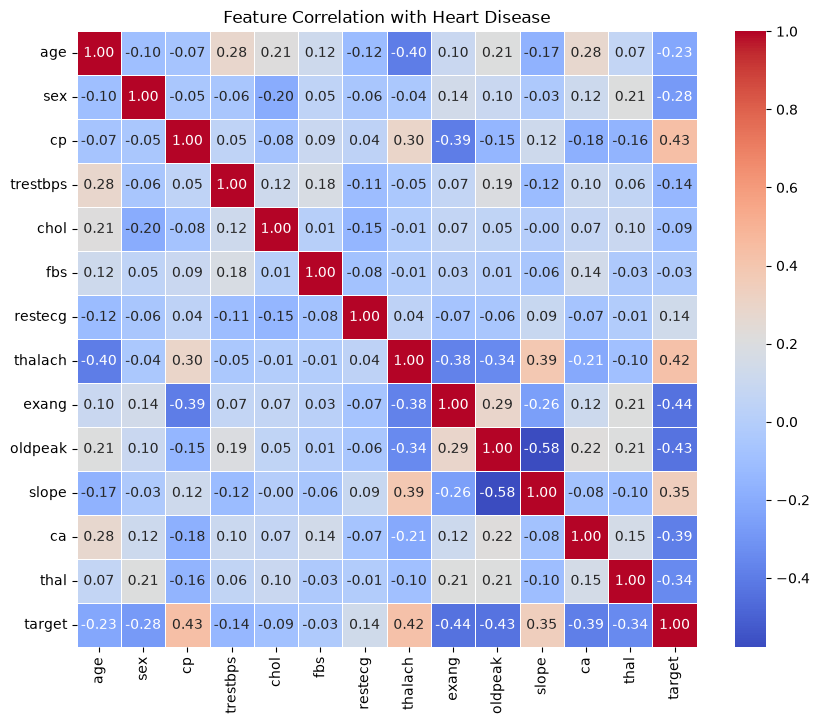

In [7]:
# now let find the correlation of dataset as it directly identifies trends
# and features affecting prediction

plt.figure(figsize=(10, 8))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Feature Correlation with Heart Disease')
plt.show()

The heatmap confirms that **cp**, **exang**, **oldpeak**, **thalach**, and **ca** are your most predictive features. A model focusing on these variables will likely capture the majority of the signal in this dataset. Features like **chol** and **fbs** may add noise if used alone but could still contribute in combination with others.

In [8]:
# Model Training
# Split features and target; stratify to maintain class balance
X = df.drop('target', axis=1)
y = df['target']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [22]:
# Scale features bcz we are using logistic
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [32]:
# Train model
model = LogisticRegression(random_state=32, max_iter=1000).fit(X_train_scaled, y_train)

In [33]:
# Generate predictions and probabilities (probabilities needed for ROC curve)
y_pred = model.predict(X_test_scaled)
y_prob = model.predict_proba(X_test_scaled)[:, 1]

In [31]:
# Accuracy of the model
print(f"Logistic Regression Accuracy: {accuracy_score(y_test, y_pred):.2%}\n")

Logistic Regression Accuracy: 80.33%



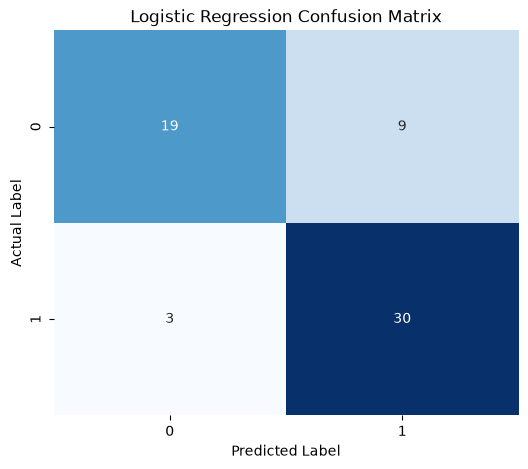

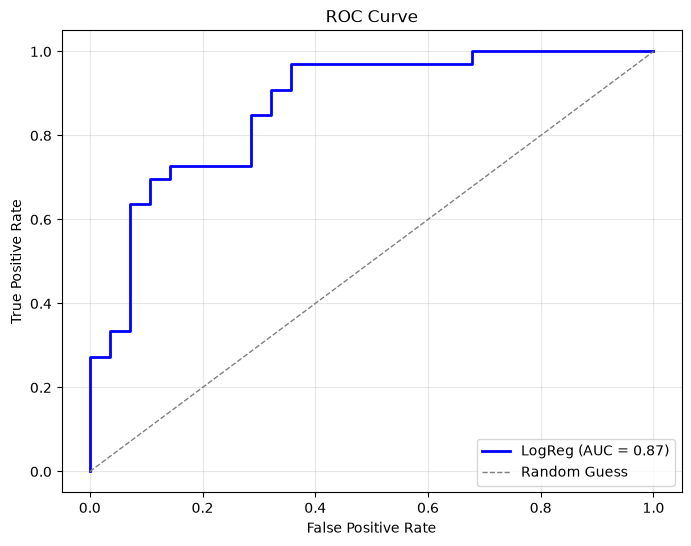

In [17]:
# Plot confusion matrix
plt.figure(figsize=(6, 5))
sns.heatmap(
    confusion_matrix(y_test, y_pred), 
    annot=True, fmt='d', cmap='Blues', cbar=False
)
plt.title('Logistic Regression Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('Actual Label')
plt.show()

# Plot ROC curve 
fpr, tpr, _ = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='blue', lw=2, label=f'LogReg (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], '--', color='gray', lw=1, label='Random Guess')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend(loc="lower right")
plt.grid(True, alpha=0.3)
plt.show()

In [35]:
# Feature Importance Highlight
importance_df = pd.DataFrame({
    'Feature': X.columns,
    'Importance': np.abs(model.coef_[0]),
}).sort_values('Importance', ascending=False)

# Display top features
print("Top Features Affecting Prediction:")
display(importance_df.head(5))

Top Features Affecting Prediction:


,Feature,Importance
2,cp,0.937735
1,sex,0.714030
12,thal,0.621578
9,oldpeak,0.594819
11,ca,0.559203
